# S&P 500: EMA 20/200 บนข้อมูลจริง 20 ปี

ใช้ราคา Yahoo Finance ช่วง 2006-09-26 ถึง 2026-09-25 และ 400 วันก่อนหน้าสำหรับ EMA
ราคาเป็นข้อมูลจริง แต่การซื้อขาย ต้นทุน และดอกเบี้ยเป็นสมมติฐาน ดัชนีราคาไม่รวมเงินปันผล

เลือก Run All ได้โดยไม่ต้องดาวน์โหลดข้อมูลเพิ่ม Snapshot ราคาและ engine ฝังใน Notebook นี้
เซลล์แรกแตกไฟล์ลงโฟลเดอร์ชั่วคราว ส่วนรายงานที่สร้างเองเขียนไว้ในโฟลเดอร์ที่รัน
เนื้อหาและตัวอย่างโค้ดถัดไปดึงจาก chapter.md เพื่อให้ตัวเลขตรงกับบทเรียน

In [1]:
from pathlib import Path
import base64, tempfile, importlib.util, sys
work_dir = Path(tempfile.mkdtemp(prefix="robo-sp500-"))
embedded_files = {'lesson_14.py': '...', 'data/sp500-daily.csv': '...', 'data/provenance.json': 'ewogICJwcm92aWRlciI6ICJZYWhvbyBGaW5hbmNlIiwKICAic3ltYm9sIjogIl5HU1BDIiwKICAibmFtZSI6ICJTJlAgNTAwIFByaWNlIEluZGV4IiwKICAiaW5zdHJ1bWVudFR5cGUiOiAiSU5ERVgiLAogICJwcmljZVVuaXQiOiAiaW5kZXggcG9pbnRzIiwKICAicG9ydGZvbGlvQ3VycmVuY3kiOiAiVVNEIiwKICAidGltZXpvbmUiOiAiQW1lcmljYS9OZXdfWW9yayIsCiAgInJldHJpZXZlZEF0VVRDIjogIjIwMjYtMDktMjZUMTM6NDI6NTEuNTM1OTkyKzAwOjAwIiwKICAic291cmNlVVJMIjogImh0dHBzOi8vcXVlcnkxLmZpbmFuY2UueWFob28uY29tL3Y4L2ZpbmFuY2UvY2hhcnQvJTVFR1NQQz9wZXJpb2QxPTExMDQ1Mzc2MDAmcGVyaW9kMj0xNzkwNDY3MjAwJmludGVydmFsPTFkIiwKICAiaGlzdG9yeVVSTCI6ICJodHRwczovL2ZpbmFuY2UueWFob28uY29tL3F1b3RlLyU1RUdTUEMvaGlzdG9yeS8iLAogICJyZXF1ZXN0ZWRTdGFydCI6ICIyMDA2LTA5LTI2IiwKICAicmVxdWVzdGVkRW5kIjogIjIwMjYtMDktMjUiLAogICJldmFsdWF0aW9uU3RhcnQiOiAiMjAwNi0wOS0yNiIsCiAgImV2YWx1YXRpb25FbmQiOiAiMjAyNi0wOS0yNSIsCiAgIndhcm11cFN0YXJ0IjogIjIwMDUtMDItMjQiLAogICJ3YXJtdXBCYXJzIjogNDAwLAogICJldmFsdWF0aW9uQmFycyI6IDUwMzEsCiAgImNhbGVuZGFyWWVhcnMiOiAxOS45OTcyNjIxNDkyMTI4NywKICAicmF3U0hBMjU2IjogImJjOGYwNThmNTRmZWYyY2Y2OGNmMDJhY2Q4YTk5NGE4ZjMwZTYyYjE1Y2Y1NTYyYzdmYjE2OTRhMzg4NmNkNGIiLAogICJjc3ZTSEEyNTYiOiAiMDk4NGNhM2Y5OGNlYjhlMzVhZTYxYzliMzA0NzdiNzRjM2I2OWE0YTc3NjRkNzIxOWNjYWFlM2JhMjhkZWRmNSIsCiAgImFkanVzdG1lbnQiOiAiVW5hZGp1c3RlZCBpbmRleCBPSExDOyBwcmljZSBpbmRleCBleGNsdWRlcyBkaXZpZGVuZHMuIE5vIEZYIGNvbnZlcnNpb24uIEluZGV4IHVuaXRzIGFyZSBhIHRlYWNoaW5nIGFic3RyYWN0aW9uLCBub3QgYSB0cmFkZWQgc2VjdXJpdHkuIgp9Cg=='}
for name, encoded in embedded_files.items():
    target = work_dir / name
    target.parent.mkdir(parents=True, exist_ok=True)
    target.write_bytes(base64.b64decode(encoded))
spec = importlib.util.spec_from_file_location("lesson_14", work_dir / "lesson_14.py")
lesson = importlib.util.module_from_spec(spec)
sys.modules["lesson_14"] = lesson
spec.loader.exec_module(lesson)
bars, backtest, report = lesson.export_all(work_dir)
print(report['provenance']['name'], report['parameters']['startDate'], report['parameters']['endDate'])
print(len(backtest['dailyEquity']), "trading days;", len(backtest['tradeLedger']), "closed trades")


S&P 500 Price Index 2006-09-26 2026-09-25
5031 trading days; 19 closed trades


# Backtest Performance Evaluation: Return, Risk, and Trading Metrics

ใน[บท Introduction of Backtest](https://nutdnuy.github.io/robo-trade-notes/chapter-13.html#tear-sheet) เราได้ทำความเข้าใจถึงวัตถุประสงค์และประเภทของการทดสอบย้อนหลังไปแล้ว ในบทนี้ เราจะมาเจาะลึกของการวัดและค่าต่าง ๆ ที่เราจะอ่าน เพื่อประเมินกลยุทธ์การลงทุนของเรา ก่อนนำไปใช้จริง

## อ่านรายงานให้ได้ และคำนวณรายงานเองด้วย Python

อย่างที่บอกในบทก่อนหน้าว่าเรา Backtest เพื่อเข้าใจพฤติกรรมของกลยุทธ์การลงทุนของเราเท่านั้น  แล้วเราจะเข้าใจมันได้อย่างไร แน่นอนว่าเราคงไม่สามารถเข้าใจมันได้เพียงแค่ ดู P&L เท่านั้น ดังนั้นในบทนี้จะนำผล Backtest หนึ่งชุดมาคำนวณทีละส่วน เพื่อให้ตอบคำถามเหล่านี้ได้จากข้อมูล

หลังจากจบบทนี้เราควรจะ 
1. อ่านตารางผล Backtest แล้วอธิบายผลตอบแทน ความเสี่ยง และกำไรขาดทุนจากการเทรด โดยไม่ใช้ตัวเลขตัวเดียวตัดสินกลยุทธ์
2. ตรวจได้ว่าตัวชี้วัดใช้ข้อมูลรายเทรดหรือผลตอบแทนรายวัน และคำนวณตัวอย่างย้อนกลับได้
3. ใช้ Python สร้างตารางตัวชี้วัด กราฟมูลค่าพอร์ต และกราฟ Drawdown ของกลยุทธ์เทียบกับ Benchmark พร้อมเขียนคำอธิบายผล

ในบทนี้เราจะใช้ตัวอย่างกลยุทธ์ที่ง่ายที่สุดกลยุทธ์หนึ่ง นั้นคิอ   EMA 20/200 บนข้อมูลราคารายวัน เราจะใช้ข้อมูลราคาจริงของดัชนี S&P 500 (^GSPC) รายวันย้อนหลัง 20 ปี ตั้งแต่ 26 กันยายน 2006 ถึง 25 กันยายน 2026 จาก Yahoo Finance ตัวเลขทั้งหมดคำนวณจากข้อมูลชุดเดียวกัน ส่วนคำสั่งซื้อขายและต้นทุนเป็นสมมติฐานของ Backtest

## Start with basic 

EMA เป็นเส้นค่าเฉลี่ยราคาที่ให้น้ำหนักกับราคาล่าสุดมากกว่าราคาเก่า เราใช้เส้นเร็ว EMA 20 และเส้นช้า EMA 200 จากราคาปิดรายวัน ตัวเลข 20 และ 200 หมายถึงช่วง 20 และ 200 เราจะเข้าซื้อเมื่อ เส้น EMA 20 อยู่สูงกว่าเส้น EMA 200 นั้นเองในทางตรงข้ามเราจะถือเงินสดเมื่อ EMA 20 ต่ำกว่าหรือเท่ากับ EMA 200 โปรแกรมตรวจเป้าหมายเมื่อสิ้นวัน แล้วส่งคำสั่งที่ราคาเปิดแท่งถัดไปเมื่อจำเป็นต้องเปลี่ยนสถานะ

| สิ่งที่กำหนด | สมมุติฐานในตัวอย่าง |
| --- | --- |
| ข้อมูลราคา | S&P 500 Price Index (^GSPC) รายวัน 5,031 วันซื้อขาย ช่วง 2006-09-26 ถึง 2026-09-25 |
| ข้อมูลตั้งต้นสำหรับ EMA | 400 วันก่อนช่วงทดสอบ ตั้งแต่ 2005-02-24 ถึง 2006-09-25 ใช้ตั้งค่า EMA ไม่รวมในผลตอบแทน |
| เงินเริ่มต้น | 100,000 USD ไม่มีเงินฝากหรือถอนระหว่างทดสอบ |
| การลงทุน | ซื้อได้เป็นเศษหน่วย ใช้เงินที่มีรวมค่าธรรมเนียม ไม่ขายชอร์ตหรือกู้เงิน |
| ต้นทุน | 10 basis points หรือ 0.10% ของมูลค่าซื้อขายในแต่ละด้าน ทั้งตอนซื้อและตอนขาย |
| การถือข้ามวัน | ถือข้ามวันได้หากสัญญาณยังให้ถือ |
| วันสุดท้าย | หากยังถืออยู่ ให้ขายปิดที่ราคาปิดสุดท้ายและคิดต้นทุน เพื่อปิดบัญชีผลทดสอบ |


เราสมมติว่าคำสั่งซื้อขายทำได้ครบตามราคา ไม่คิดส่วนต่างราคาซื้อขาย ความคลาดเคลื่อนของราคาที่ซื้อขายได้ ภาษี เงินปันผล และดอกเบี้ยเงินสด ผลในบทจึงรวมเฉพาะต้นทุนที่ระบุในตารา

กลยุทธ์นี้ตรวจสัญญาณวันละครั้งหลังทราบราคาปิด หากเป้าหมายยังเหมือนเดิมก็ถือสถานะต่อ เมื่อ EMA 20 วันตัดขึ้นเหนือ EMA 200 วันจึงซื้อที่ราคาเปิดวันซื้อขายถัดไป และขายที่ราคาเปิดวันถัดจากสัญญาณตัดลง 

:



ดาวน์โหลด[ชุดไฟล์ประกอบบท](robo-trade-performance-review.zip) แล้วแตกไฟล์ เริ่มรันโค้ดในโฟลเดอร์ที่มี `lesson_14.py`, `ema-bars.csv`, `trades.csv` และ `equity-daily.csv` โค้ดนี้ใช้ Python 3 โดยไม่ต้องติดตั้งไลบรารีเพิ่มเติม หากต้องการรันทีละขั้นใน Notebook ให้ใช้ไฟล์ที่ส่วนท้ายบท

In [2]:
import csv
from pathlib import Path
from lesson_14 import trade_metrics, portfolio_metrics

with (work_dir / "trades.csv").open(newline="", encoding="utf-8") as f:
    trades = list(csv.DictReader(f))
with (work_dir / "equity-daily.csv").open(newline="", encoding="utf-8") as f:
    daily = list(csv.DictReader(f))

pnl = [float(row["netPnl"]) for row in trades]
equity = [100_000.0] + [float(row["equity"]) for row in daily]
benchmark = [100_000.0] + [float(row["benchmarkEquity"]) for row in daily]
returns = [b / a - 1 for a, b in zip(equity, equity[1:])]

`pnl` เก็บกำไรขาดทุนสุทธิ 19 เทรด เราให้เงินเริ่มต้นเท่ากับหนึ่งค

### สูตร EMA และช่วงเตรียมข้อมูล

หากกำหนดช่วงของ EMA เท่ากับ $n$ จะให้น้ำหนักกับราคาปิดล่าสุดด้วย $\alpha=2/(n+1)$ แล้วคำนวณต่อจากค่าเดิม

$$
\mathrm{EMA}_t=\alpha C_t+(1-\alpha)\mathrm{EMA}_{t-1}.
$$

$C_t$ คือราคาปิดล่าสุด ค่า EMA ยังได้รับผลจากราคาเก่าผ่านค่า EMA ก่อนหน้า จึงไม่ใช่การนำราคา 20 หรือ 200 แท่งมาบวกหารตรง ๆ แบบค่าเฉลี่ยธรรมดา




## Total Return และ CAGR: เงินเพิ่มหรือลดเท่าไร

หลังหักต้นทุน เงินเริ่มต้น 100,000 USD เปลี่ยนเป็น 297,983.16 USD กำไรขาดทุนสุทธิเท่ากับ 197,983.16 USD เมื่อนำกำไรขาดทุนหารด้วยเงินเริ่มต้น จะได้ Total Return หรือผลตอบแทนสะสม

$$
\mathrm{Total\ Return}
=\frac{\text{เงินปลายทาง}-\text{เงินเริ่มต้น}}{\text{เงินเริ่มต้น}}
\approx\frac{297983.16-100000}{100000}
\approx197.9832\%.
$$

ตัวเลขนี้บอกผลตลอดช่วงทดสอบ แต่ไม่ได้บอกว่าต้องผ่านช่วงขาดทุนใดบ้าง หากจะเปรียบเทียบกับกลยุทธ์อื่น ต้องใช้ช่วงเวลาเดียวกัน

CAGR คืออัตราเติบโตทบต้นเฉลี่ยต่อปี เป็นอัตราคงที่ที่ทำให้เงินเริ่มต้นกลายเป็นเงินปลายทางเดียวกัน ช่วง 26 กันยายน 2006 ถึง 25 กันยายน 2026 ห่างกัน 7,304 วันปฏิทิน คิดเป็น $Y=7304/365.25\approx19.9973$ ปี ได้ CAGR 5.6119% ต่อปี ส่วน Total Return 197.9832% วัดผลสะสมตลอดช่วง

$$
\mathrm{CAGR}
=\left(\frac{\text{เงินปลายทาง}}{\text{เงินเริ่มต้น}}\right)^{1/Y}-1,
\qquad Y=7304/365.25.
$$

หากมีข้อมูลหลายปี สูตรจะเปลี่ยนผลทั้งช่วงให้เป็นอัตราต่อปีโดยคิดทบต้น ไม่ใช่นำ Total Return ไปหารจำนวนปี และไม่ได้บอกว่าแต่ละปีทำผลตอบแทนได้เท่ากันจริง

ใน Python หาก `equity` เก็บเงินเริ่มต้นตามด้วยมูลค่าพอร์ตสิ้นวันทุกวัน จะคำนวณได้ดังนี้

In [3]:
total_return = equity[-1] / equity[0] - 1
from datetime import date
years = (date.fromisoformat(daily[-1]["date"])
         - date.fromisoformat(daily[0]["date"])).days / 365.25
cagr = (equity[-1] / equity[0]) ** (1 / years) - 1

ค่าเฉลี่ยผลตอบแทนรายวันของพอร์ตนี้คือ 0.024840% เป็นการนำผลตอบแทนทุกวันมาบวกแล้วหารจำนวนวัน หากแสดงค่าเฉลี่ยดังกล่าวเป็นรายปีด้วยการคูณ 252 จะได้ 6.2597% 


### ผลตอบแทนรายวันและการรวมผลหลายวัน

ถ้าวันก่อนพอร์ตมีมูลค่า $V_{t-1}$ และวันนี้มีมูลค่า $V_t$ ผลตอบแทนวันนี้คือ

$$
r_t=\frac{V_t}{V_{t-1}}-1.
$$

ใน Python ใช้ `returns = [b / a - 1 for a, b in zip(equity, equity[1:])]` จะได้ 5,031 ค่าสำหรับช่วงทดสอบนี้ เมื่อเชื่อมผลของหลายวันต้องคูณ $(1+r_t)$ ต่อกัน เพราะฐานเงินเปลี่ยนไปในแต่ละวัน การบวกเปอร์เซ็นต์ตรง ๆ จึงไม่ใช่ผลตอบแทนสะสม

สูตรจากเงินต้นและเงินปลายทางนี้ใช้ได้เพราะไม่มีเงินฝากถอนระหว่างทาง หากมี ต้องแยกเงินที่เข้าออกออกจากผลลงทุนก่อน และหากพอร์ตมีมูลค่าศูนย์หรือติดลบ จะตีความ CAGR ด้วยสูตรนี้ตามปกติไม่ได้



## Win Rate และกำไรขาดทุนเฉลี่ย: ชนะกี่ครั้ง ได้ครั้งละเท่าไร

Win Rate คือสัดส่วนของเทรดที่ปิดแล้วได้กำไรสุทธิ ใช้ตอบว่า “ในเทรดที่จบทั้งหมด เราชนะบ่อยแค่ไหน” ส่วน Loss Rate คือสัดส่วนของเทรดที่ปิดแล้วขาดทุนสุทธิ ทั้งสองค่าหารด้วยจำนวนเทรดที่ปิดทั้งหมด

หนึ่งเทรดหมายถึงการซื้อแล้วขายปิดครบหนึ่งรอบ หากซื้อวันนี้และขายในอีกสามวัน เรายังนับเป็นหนึ่งเทรด ไม่ได้นับแต่ละวันเป็นเทรดใหม่ การชนะหรือแพ้ใช้กำไรขาดทุนหลังหักต้นทุนซื้อขายแล้ว

ผล EMA ชุดนี้ปิดทั้งหมด 19 เทรด มีกำไรสุทธิ 8 เทรด และขาดทุนสุทธิ 11 เทรด จึงคำนวณได้ดังนี้

$$
\mathrm{Win\ Rate}=\frac{8}{19}\approx42.1053\%,
\qquad
\mathrm{Loss\ Rate}=\frac{11}{19}\approx57.8947\%.
$$

Win Rate 42.1053% อ่านว่า ใน 19 เทรดที่ผ่านมา มีประมาณ 42% หรือ 8 เทรดที่ได้กำไร ส่วน Loss Rate 57.8947% หมายถึงอีก 11 เทรดขาดทุน กลยุทธ์นี้จึงแพ้บ่อยกว่าชนะในช่วงทดสอบ แต่ยังสรุปไม่ได้ว่าขาดทุนรวม เพราะต้องดูด้วยว่าตอนชนะได้กำไรเท่าไร และตอนแพ้เสียเท่าไร

สัดส่วนนี้อธิบายผล 19 เทรดที่เกิดขึ้นแล้ว ไม่ได้รับประกันว่า 100 เทรดถัดไปจะชนะ 42 ครั้ง และไม่ใช่สัดส่วนวันที่พอร์ตมีกำไร เพราะเทรดเดียวอาจถือผ่านทั้งวันที่ราคาขึ้นและลง



เลือกเทรดหนึ่งรายการเพื่อตรวจราคาซื้อ ราคาขาย จำนวนหน่วย และค่าใช้จ่าย จากนั้นเทียบกำไรขาดทุนสุทธิของรายการนั้นกับผลรวมที่นำไปคำนวณในรายงาน

ตัวอย่าง T1 ซื้อที่ดัชนี 1,326.3500 จุด ขายที่ 1,440.7400 จุด จำนวน 75.3196 หน่วยตามแบบจำลอง ส่วนต่างราคาคูณจำนวนหน่วยได้กำไรก่อนต้นทุน 8,615.81 USD หักต้นทุนซื้อและขายรวม 208.42 USD เหลือกำไรสุทธิ 8,407.39 USD โค้ดใช้ค่าราคาเต็มก่อนปัดทศนิยมแสดงผล

Average Win คือกำไรสุทธิเฉลี่ยต่อเทรดที่ชนะ คำนวณโดยรวมกำไรของเฉพาะเทรดที่ชนะแล้วหารด้วยจำนวนเทรดที่ชนะ ส่วน Average Loss คือขนาดขาดทุนสุทธิเฉลี่ยต่อเทรดที่แพ้ คำนวณจากเฉพาะกลุ่มที่แพ้ จึงใช้จำนวนเทรดคนละกลุ่มเป็นตัวหาร

ในตัวอย่าง เทรดชนะ 8 เทรดทำกำไรสุทธิรวม 278,962.81 USD ส่วนเทรดแพ้ 11 เทรดขาดทุนสุทธิรวม 80,979.64 USD จึงได้ค่าเฉลี่ยดังนี้

$$
\mathrm{Average\ Win}\approx\frac{278962.81}{8}\approx34{,}870.35\ \text{USD},
$$

$$
\mathrm{Average\ Loss}\approx\frac{80979.64}{11}\approx7{,}361.79\ \text{USD}.
$$

Average Win 34,870.35 USD หมายถึง เมื่อดูเฉพาะ 8 เทรดที่ชนะ แต่ละเทรดได้กำไรสุทธิเฉลี่ย 34,870.35 USD ส่วน Average Loss 7,361.79 USD หมายถึง เมื่อดูเฉพาะ 11 เทรดที่แพ้ แต่ละเทรดเสียเงินสุทธิเฉลี่ย 7,361.79 USD เราไม่ได้หารทั้งสองยอดด้วย 19 เพราะกำลังหาค่าเฉลี่ยแยกกลุ่มชนะและแพ้

เราเขียน Average Loss เป็นจำนวนบวกเพื่อบอกขนาดเงินที่เสียไป เช่น 7,361.79 USD ในที่นี้หมายถึงขาดทุน ไม่ใช่กำไร เวลาใช้คำนวณกำไรขาดทุนรวมจึงนำจำนวนนี้ไปลบ ค่าเฉลี่ยทั้งสองไม่ได้แปลว่าทุกเทรดจะได้หรือเสียเงินเท่ากัน

ใน Python ให้ `pnl` เป็นรายการกำไรขาดทุนสุทธิของแต่ละเทรด แล้วแยกค่าบวกกับค่าลบก่อนหาค่าเฉลี่ย

In [4]:
wins = [x for x in pnl if x > 0]
losses = [-x for x in pnl if x < 0]
win_rate = len(wins) / len(pnl) if pnl else None
loss_rate = len(losses) / len(pnl) if pnl else None
average_win = sum(wins) / len(wins) if wins else None
average_loss = sum(losses) / len(losses) if losses else None

ค่าเฉลี่ยหน่วย USD ขึ้นกับจำนวนเงินที่ใช้ซื้อขายด้วย ตัวอย่างนี้นำเงินที่เหลือไปลงทุนรอบถัดไป ขนาดสถานะจึงเปลี่ยนตามพอร์ต เทรดที่ใช้เงินมากอาจได้หรือเสียเป็น USD มากกว่า แม้ราคาเปลี่ยนในอัตราใกล้กัน หากต้องการเปรียบเทียบแต่ละเทรด ต้องอ่านจำนวนเงินลงทุนและผลตอบแทนเป็นเปอร์เซ็นต์ประกอบ



กราฟการแจกแจงแสดงว่ากำไรขาดทุนแต่ละไม้กระจายอยู่ช่วงใด แกนนอนคือกำไรขาดทุนสุทธิต่อเทรด หน่วย USD ด้านซ้ายของศูนย์คือเทรดแพ้ ด้านขวาคือเทรดชนะ ส่วนความสูงของแท่งบอกจำนวนเทรดในช่วงนั้น จุดแต่ละจุดแทนหนึ่งเทรด เพื่อให้ตรวจผลทั้ง 19 ไม้ได้โดยไม่ต้องสรุปจากค่าเฉลี่ยเพียงค่าเดียว

เส้น Average Win อยู่ที่ +34,870.35 USD ส่วนเส้น Average Loss อยู่ที่ −7,361.79 USD บนกราฟ เส้นหลังอยู่ด้านลบเพื่อระบุตำแหน่งขาดทุน แม้สูตร Average Loss ข้างต้นจะแสดงขนาดเป็นจำนวนบวก

ผล 14 จาก 19 เทรดอยู่ระหว่าง −20,000 ถึง +20,000 USD อีก 5 เทรดเป็นกำไรที่มากกว่า 20,000 USD ฝั่งขาดทุนมีไม้ที่เสียมากที่สุดคือ T15 ประมาณ −17,730.43 USD ส่วนไม้กำไรสูงสุดคือ T19 ประมาณ +69,362.18 USD ผลจึงกระจายไม่สมมาตร และกำไรเฉลี่ยได้รับอิทธิพลจากไม้กำไรใหญ่

เมื่อรวม T19 กับ T14 ซึ่งเป็นสองไม้กำไรสูงสุด จะได้ 131,845.40 USD หรือ 47.26% ของกำไรสุทธิที่รวมจากเทรดชนะทั้ง 8 ไม้ สัดส่วนนี้ใช้ยอดกำไรฝั่งชนะเป็นฐาน ไม่ใช่กำไรสุทธิของทั้งพอร์ตหลังหักเทรดแพ้ กราฟจึงช่วยอธิบายว่ากลยุทธ์ชนะน้อยกว่าครึ่ง แต่ยังมีกำไรรวมจากไม้ชนะที่มีขนาดใหญ่ได้อย่างไร

ข้อมูลมีเพียง 19 เทรด เราจึงอ่านเป็นการแจกแจงผลที่สังเกตได้ในช่วงนี้ ยังไม่ใช้ยืนยันรูปแบบการแจกแจงในอนาคตหรือครอบด้วยเส้นโค้งปกติ และต้องจำว่า T19 ถูกปิดตามวันสิ้นสุด Backtest ผลของไม้ดังกล่าวจึงขึ้นกับวันที่เลือกจบการทดสอบด้วย



## Payoff, Expectancy และ Profit Factor: รวมความถี่กับขนาดกำไร

Win Rate บอกจำนวนครั้ง แต่ยังไม่บอกว่าชนะหนึ่งครั้งชดเชยการแพ้ได้เท่าไร Payoff Ratio นำกำไรเฉลี่ยมาหารด้วยขนาดขาดทุนเฉลี่ย

$$
\mathrm{Payoff\ Ratio}
\approx\frac{34870.35}{7361.79}
\approx4.7367.
$$

อ่านว่า กำไรเฉลี่ยหนึ่งครั้งมีขนาดประมาณ 4.7367 เท่าของขาดทุนเฉลี่ยหนึ่งครั้ง ตัวเลขนี้ต้องอ่านคู่กับสัดส่วนชนะ เพราะชนะบ่อยแต่อัตราส่วนต่ำมากก็อาจขาดทุนรวมได้

Expectancy คือกำไรขาดทุนเฉลี่ยต่อเทรดที่ประมาณจากข้อมูล เราหาได้ทั้งจากกำไรขาดทุนสุทธิรวมหารจำนวนเทรด และจากการถ่วงขนาดกำไรขาดทุนด้วยสัดส่วนชนะและแพ้

$$
\mathrm{Expectancy}
\approx\frac{197983.16}{19}
\approx10420.17\ \text{USD ต่อเทรด}.
$$

$$
\mathrm{Expectancy}
=(\text{สัดส่วนชนะ}\times\text{กำไรเฉลี่ย})
-(\text{สัดส่วนแพ้}\times\text{ขาดทุนเฉลี่ย}).
$$

ค่าที่ได้เป็นค่าเฉลี่ยย้อนหลัง เทรดถัดไปไม่จำเป็นต้องได้ผลเท่านี้ และการเพิ่มจำนวนเงินต่อเทรดสามารถเพิ่มทั้ง Expectancy หน่วย USD และความเสียหายที่ต้องรับได้

ผล EMA ชุดนี้ชนะเพียง 42.1053% แต่ Payoff Ratio เท่ากับ 4.7367 กำไรเฉลี่ยของเทรดชนะจึงชดเชยเทรดแพ้ได้หลายครั้ง เกณฑ์เสมอตัวอยู่ที่ Win Rate ประมาณ 17.4317% และเกิดกำไรเฉลี่ย 10,420.17 USD ต่อเทรด ผลจริงชุดนี้แสดงว่าชนะน้อยกว่าครึ่งยังมีกำไรได้ การอ่าน Win Rate เพียงตัวเดียวจึงไม่พอบอกผลรวม



ลองกรอก Win Rate เป็น 10% โดยคงขนาดกำไรและขาดทุนเฉลี่ยจากผลจริงไว้ จะได้ Expectancy ประมาณ −3,138.57 USD ต่อเทรด เพราะต่ำกว่าเกณฑ์เสมอตัว 17.43% จากนั้นกดกลับผล EMA ตั้งต้น การทดลองนี้เปลี่ยนสมมติฐานในสูตร ไม่ใช่ผล Backtest ที่เกิดขึ้นจริง

การชนะบ่อยก็ไม่ได้รับรองกำไรเช่นกัน จากสูตร เมื่อ Win Rate 60% จะต้องมี Payoff มากกว่า $0.40/0.60=0.6667$ จึงได้ Expectancy เป็นบวก ลองลด Payoff ในห้องทดลองเพื่อดูจุดที่ผลเปลี่ยนเครื่องหมาย ตัวเลข 60% นี้เป็นโจทย์ทดลองสมการ แยกจากผลจริง 42.1053% ข้างต้น

Profit Factor หรือ PF เปรียบเทียบกำไรรวมจากเทรดชนะกับขาดทุนรวมจากเทรดแพ้

$$
\mathrm{PF}
\approx\frac{278962.81}{80979.64}
\approx3.4449.
$$

ถ้า PF มากกว่า 1 แปลว่ากำไรรวมมากกว่าขาดทุนรวม ถ้าต่ำกว่า 1 แปลว่าขาดทุนรวมมากกว่า ค่า PF ไม่ใช่สัดส่วนเงินปลายทางต่อเงินต้น เพราะจำนวนที่นำมาหารคือขาดทุนรวมของเทรดที่แพ้

In [5]:
payoff = average_win / average_loss if average_loss and average_win is not None else None
expectancy = sum(pnl) / len(pnl) if pnl else None
profit_factor = sum(wins) / sum(losses) if losses else None

ทั้งสามตัวชี้วัดไม่บอกลำดับของกำไรขาดทุน หากแพ้หลายครั้งติดกัน พอร์ตอาจลดลงมากแม้ผลรวมทั้งช่วงเป็นบวก เราจึงต้องดู Drawdown ต่อจากสถิติรายเทรด

### สูตรเชื่อม Win Rate, Payoff และ Expectancy

ให้ $p_W$ และ $p_L$ เป็นสัดส่วนชนะและแพ้, $\overline W$ เป็นกำไรเฉลี่ย, $\overline L$ เป็นขนาดขาดทุนเฉลี่ย และ $b=\overline W/\overline L$ เป็น Payoff Ratio

$$
\widehat E=p_W\overline W-p_L\overline L,
\qquad
\mathrm{PF}=\frac{p_Wb}{p_L}.
$$

เมื่อไม่มีเทรดเสมอตัว สัดส่วนชนะที่ทำให้ Expectancy เท่ากับศูนย์คือ $1/(1+b)$ เมื่อใช้ $b=4.7367$ จากผลจริง จึงได้เกณฑ์เสมอตัวประมาณ 17.43%

ถ้าไม่มีเทรดแพ้ จะไม่มีขาดทุนเฉลี่ยสำหรับหา Payoff และไม่มีผลรวมขาดทุนสำหรับหา PF ให้รายงานข้อจำกัดนี้พร้อมจำนวนเทรด อย่าตีความค่าที่หารด้วยศูนย์ว่าเป็นหลักฐานว่ากลยุทธ์ดีแน่นอน



## จำนวนเทรดและต้นทุน: กำไรส่วนใดถูกใช้จ่ายไป

ตัวอย่างคิดต้นทุน 0.10% ของมูลค่าที่ซื้อและ 0.10% ของมูลค่าที่ขาย ไม่ใช่หัก 0.10% เพียงครั้งเดียวต่อเทรด และยอดที่ขายอาจไม่เท่ากับยอดที่ซื้อเมื่อราคาเปลี่ยน

ผลรวมกำไรขาดทุนจากราคาซื้อขายก่อนหักค่าใช้จ่ายของรายการที่เกิดขึ้นจริงเท่ากับ 203,638.80 USD มีต้นทุนรวม 5,655.64 USD จึงเหลือกำไรขาดทุนสุทธิ 197,983.16 USD

$$
\text{กำไรขาดทุนสุทธิ}
=\text{กำไรขาดทุนจากราคา}-\text{ต้นทุนที่จ่าย}.
$$

ต้นทุนอยู่ในมูลค่าพอร์ตและกำไรขาดทุนสุทธิรายเทรดแล้ว จึงไม่นำมาหักซ้ำตอนคำนวณ Total Return หรือ Expectancy หนังสือแสดงผลของต้นทุนต่อกลยุทธ์ที่ซื้อขายถี่ในหน้า PDF 94 และเชื่อมจำนวนครั้งซื้อขายกับต้นทุนในหน้า 156 [1]

จำนวนเทรดที่ปิด 19 รอบต่างจากจำนวนคำสั่ง 38 คำสั่ง การเปิดและปิดหนึ่งรอบใช้คำสั่งคนละด้าน ส่วนการตรวจสัญญาณที่ทุกแท่งยังไม่ใช่คำสั่งซื้อขาย

รอบนี้มีเทรดสุดท้าย T19 ที่ยังไม่เกิดสัญญาณขาย จึงปิดที่ราคาปิดวันที่ 25 กันยายน 2026 และบันทึก `forced_end` เทรดนี้รวมอยู่ในผล 19 รอบแล้ว ผลจะเปลี่ยนหากเลือกวันสิ้นสุดอื่น ต้องรายงานวิธีปิดสถานะพร้อมตัวเลขเสมอ

จำนวนเทรดช่วยบอกขนาดข้อมูลที่ใช้คำนวณ แต่จำนวนมากไม่ได้แปลว่าได้ทดสอบหลายสภาพตลาด หากเทรดทั้งหมดเกิดในช่วงแนวโน้มคล้ายกัน ผลยังอาจเปลี่ยนเมื่อภาวะตลาดเปลี่ยน

### ตรวจขนาดซื้อขายและต้นทุนใน Python

ถ้ามีเงินสด $C$ ซื้อที่ราคา $P$ และต้นทุนด้านซื้อเป็นสัดส่วน $c=0.001$ จำนวนหน่วยสูงสุดที่ซื้อพร้อมจ่ายค่าธรรมเนียมได้คือ

$$
q=\frac{C}{P(1+c)}.
$$

การยอมให้ซื้อเศษหน่วยทำให้สูตรนี้ใช้เงินได้ครบตามสมมติฐาน เมื่อขาย จะได้รับเงิน $qP_{\mathrm{sell}}(1-c)$ การคิดค่าธรรมเนียมตามมูลค่าซื้อขายทำให้เงินที่ลงทุนรอบถัดไปเปลี่ยนไปด้วย

หากรันทดสอบใหม่ด้วยต้นทุนเป็นศูนย์ ขนาดซื้อในแต่ละรอบอาจเพิ่มตามเงินที่เหลือ ผลต่างของเงินปลายทางระหว่างสองรอบจึงไม่จำเป็นต้องเท่ากับค่าธรรมเนียมที่จ่ายในรอบเดิมพอดี ต้องแยกการรวมค่าใช้จ่ายจากรายการเดิมออกจากการรันสมมติฐานใหม่

จำนวนคำสั่งยังต่างจากจำนวนการจับคู่ซื้อขายจริง หรือ Fill ในตัวอย่างสมมติให้คำสั่งทำได้ครบที่ราคาที่กำหนด ไม่ได้จำลองคำสั่งที่ทำได้เพียงบางส่วนหรือผลกระทบต่อราคาจากคำสั่งขนาดใหญ่



## Maximum Drawdown: พอร์ตเคยต่ำกว่ายอดเดิมเท่าไร

ก่อนเกิด MDD พอร์ตขึ้นถึง 125,676.19 USD วันที่ 23 เมษายน 2010 แล้วลดลงถึง 91,738.17 USD วันที่ 28 ธันวาคม 2011 เมื่อนำส่วนที่ลดลงหารด้วยยอดเดิม จะได้ Drawdown ของช่วงนั้น

$$
\mathrm{Drawdown}
\approx\frac{91738.17}{125676.19}-1
\approx-27.0043\%.
$$

นี่คือ Drawdown ที่ลึกที่สุดจากข้อมูลสิ้นวัน จึงเรียกว่า Maximum Drawdown หรือ MDD บทนี้รายงานเป็นค่าติดลบ ยิ่งติดลบมากยิ่งลดลงจากยอดเดิมมาก ฐานเปรียบเทียบคือยอดสูงสุดก่อนหน้า ไม่ใช่เงินเริ่มต้นเสมอไป



เลือกจุดยอดก่อนการลดลงแล้วเลื่อนไปยังจุดต่ำสุด อ่านยอดเดิม มูลค่าที่ลดลง และเปอร์เซ็นต์จากจุดเดียวกัน เส้นพอร์ตช่วยให้เห็นจำนวนเงิน ส่วนกราฟ Drawdown ช่วยแสดงระยะห่างจากยอดเดิมทุกวัน

MDD บอกว่าพอร์ตลดลงลึกที่สุดเท่าไร ส่วนระยะเวลาบอกว่าเงินใช้เวลาลงและฟื้นนานเพียงใด เราแบ่งช่วงที่เกิด MDD โดยใช้สามจุด คือยอดเดิม จุดต่ำสุด และวันแรกที่มูลค่าพอร์ตกลับถึงหรือสูงกว่ายอดเดิม

| ระยะเวลา | เริ่มและสิ้นสุดตรงไหน | ผลของช่วง MDD นี้ |
| --- | --- | --- |
| Drawdown period | จากยอดเดิมถึงจุดต่ำสุด | 23 เมษายน 2010 → 28 ธันวาคม 2011 รวม 425 วันซื้อขาย |
| Recovery period | จากจุดต่ำสุดจนกลับถึงยอดเดิม | 28 ธันวาคม 2011 → 18 กันยายน 2013 รวม 432 วันซื้อขาย |
| Underwater period | จากยอดเดิมจนกลับถึงยอดเดิม ครอบคลุมทั้งช่วงลงและช่วงฟื้น | 23 เมษายน 2010 → 18 กันยายน 2013 รวม 857 วันซื้อขาย |



ในช่วงลง 425 วันซื้อขาย พอร์ตลดจากยอด 125,676.19 USD ถึงจุดต่ำสุด 91,738.17 USD หลังจากนั้นใช้เวลาอีก 432 วันซื้อขายจึงกลับถึงยอดเดิม รวมเวลาที่ต้องรอจากยอดเดิมถึงการฟื้นครบเป็น $425+432=857$ วันซื้อขาย คำว่า “ช่วงลง” และ “ช่วงฟื้น” ระบุจุดเริ่มกับจุดจบ พอร์ตยังขึ้นลงสลับกันภายในแต่ละช่วงได้

บทนี้นับระยะเวลาเป็นจำนวนช่วงวันซื้อขายระหว่างสองจุด โดยให้จุดเริ่มเป็นวัน 0 จึงไม่บวกวันเริ่มซ้ำ และไม่รวมวันหยุดเป็นวันซื้อขาย ชื่อ Drawdown duration หรือ Recovery ในรายงานอื่นอาจนับจากจุดต่างกัน จึงต้องตรวจนิยามก่อนนำระยะเวลามาเปรียบเทียบ

ช่วงที่ขาดทุนลึกที่สุดไม่จำเป็นต้องเป็นช่วงที่จมอยู่ใต้ยอดเดิมนานที่สุด MDD วัดความลึก ส่วน Underwater period วัดเวลาที่พอร์ตยังไม่กลับถึงยอดเดิม นักลงทุนจึงควรดูทั้งสองอย่างเพื่อประเมินขนาดขาดทุนและระยะเวลาที่ต้องรอ

ช่วง MDD ข้างต้นฟื้นแล้วในปี 2013 แต่ ณ วันสิ้นข้อมูล 25 กันยายน 2026 พอร์ตอยู่ในช่วงลดลงอีกรอบ และผ่านไป 30 วันซื้อขายนับจากยอดล่าสุด ตัวเลข 30 วันนี้เป็นคนละช่วงกับ 857 วันข้างต้น ต้องแสดงว่า “ยังไม่ฟื้นตัว ณ สิ้นสุดการทดสอบ” และรายงานเวลาที่ผ่านไปถึงวันสุดท้าย เรายังไม่ทราบ Underwater period ทั้งช่วงหรือ Recovery period ที่ครบแล้ว จึงไม่เติมค่าระยะเวลาฟื้นเป็นศูนย์

จากจุดต่ำสุด ต้องได้ผลตอบแทนประมาณ 36.9944% จึงกลับถึงยอดเดิม คำนวณจากยอดเดิมหารด้วยมูลค่าที่จุดต่ำสุดแล้วลบหนึ่ง ฐานเงินตอนฟื้นต่ำลง จึงต้องเพิ่มเป็นเปอร์เซ็นต์มากกว่าขนาดเปอร์เซ็นต์ที่ลดลง

In [6]:
peak = equity[0]
drawdown = []
for value in equity:
    peak = max(peak, value)
    drawdown.append(value / peak - 1)
maximum_drawdown = min(drawdown)

รายงานนี้ใช้มูลค่าพอร์ตสิ้นวันทั้งการคำนวณผลตอบแทนและ Drawdown จึงไม่เห็นความเคลื่อนไหวทุกจุดระหว่างวัน ค่า MDD ย้อนหลังไม่รับรองว่าการขาดทุนในอนาคตจะไม่เกินนี้

### สูตรและระยะเวลาของ Drawdown

ให้ $V_t$ เป็นมูลค่าพอร์ต และ $H_t$ เป็นมูลค่าสูงสุดตั้งแต่เริ่มจนถึงวันนั้น

$$
H_t=\max_{u\leq t}V_u,
\qquad
D_t=\frac{V_t}{H_t}-1,
\qquad
\mathrm{MDD}=\min_t D_t.
$$

หนังสือหน้า PDF 279 แสดงการลดลงเป็นจำนวนบวกจาก $(H_t-V_t)/H_t$ บทนี้กลับเครื่องหมายเพื่อให้กราฟอยู่ต่ำกว่าศูนย์ แต่ใช้ระยะห่างเดียวกัน ส่วนหน้า 280 วัดช่วงเวลาระหว่างจุดที่กลับถึงยอด [1]

การนับวันในข้อมูลชุดนี้ใช้วันซื้อขาย ไม่ใช่วันปฏิทิน ระยะเวลาช่วงที่ยังไม่ฟื้นจนถึงวันสุดท้ายต้องแสดงแยกจากช่วงที่ฟื้นครบแล้ว และไม่ต้องปรับ MDD ให้เป็นรายปี



## Volatility: ผลตอบแทนรายวันแกว่งมากเพียงใด

พอร์ตมีวันที่ผลตอบแทนเป็นบวก 2,192 วัน เป็นลบ 1,819 วัน และเป็นศูนย์ 1,020 วัน เรารวมทุกวันในการประเมินพอร์ต รวมวันที่ถือเงินสดด้วย ผลตอบแทนเฉลี่ยเท่ากับ 0.024840% ต่อวัน

Volatility ในบทนี้วัดว่าผลตอบแทนแต่ละวันห่างจากค่าเฉลี่ยมากน้อยเพียงใด โดยใช้ส่วนเบี่ยงเบนมาตรฐานของตัวอย่าง (Standard Deviation หรือ SD) คำนวณจากผลตอบแทนครบ 5,031 วันได้ 0.789898% ต่อวัน แล้วแสดงเป็นรายปีดังนี้

$$
\mathrm{Volatility}_{\mathrm{year}}
=0.789898\%\times\sqrt{252}
\approx12.5392\%.
$$

In [7]:
from math import sqrt
from statistics import mean, stdev

daily_mean = mean(returns)
daily_volatility = stdev(returns)
annual_volatility = daily_volatility * sqrt(252)

ค่าที่สูงขึ้นหมายถึงผลตอบแทนห่างจากค่าเฉลี่ยมากขึ้น โดยนับทั้งการแกว่งขึ้นและลง จึงไม่ใช่ขาดทุนสูงสุด หากต้องการดูว่าพอร์ตเคยลดจากยอดเท่าไร ต้องใช้ Drawdown ประกอบ

เราใช้ผลตอบแทนรายวันจึงคูณด้วยรากที่สองของ 252 ซึ่งเป็นจำนวนวันซื้อขายต่อปีตามสมมติฐาน ไม่ได้คูณด้วยรากของ 5,031 แม้ชุดข้อมูลจะมี 5,031 วัน เพราะจำนวนนั้นคือความยาวข้อมูลประมาณ 20 ปี

### เหตุใดจึงใช้รากที่สอง และสูตรคำนวณคืออะไร

ให้ $r_t$ เป็นผลตอบแทนของแต่ละวัน, $\bar r$ เป็นค่าเฉลี่ย และ $N$ เป็นจำนวนวัน

$$
s_r=\sqrt{\frac{\sum_{t=1}^{N}(r_t-\bar r)^2}{N-1}}.
$$

ขั้นตอนคือหักค่าเฉลี่ยออกจากแต่ละวัน ยกกำลังสอง รวมทั้งหมด หารด้วยจำนวนวันลบหนึ่ง แล้วถอดรากที่สอง `statistics.stdev` ใช้สูตรนี้

วิธีแสดงเป็นรายปีแบบย่อให้ความแปรปรวนสะสมตามจำนวนวัน ส่วนเบี่ยงเบนมาตรฐานเป็นรากที่สองของความแปรปรวน จึงคูณด้วย $\sqrt{252}$ แทนการคูณ 252 ตรง ๆ หนังสือแสดงการคำนวณนี้ในหน้า PDF 85 และ 278 [1]

หากผลตอบแทนแต่ละวันมีความสัมพันธ์ต่อเนื่องกัน วิธีปรับด้วยรากของเวลาอาจไม่สะท้อนความผันผวนระยะยาวได้ดี และการคำนวณนี้ไม่ได้รับรองว่าผลตอบแทนต้องกระจายแบบปกติ



## Sharpe และ Sortino: ผลตอบแทนเมื่อเทียบกับความเสี่ยง

Sharpe Ratio ใช้ผลตอบแทนที่เกินจากอัตราปลอดความเสี่ยงมาหารด้วยความผันผวน เราสมมติอัตราปลอดความเสี่ยงเป็น 0% ในตัวอย่างนี้ ดังนั้นผลตอบแทนส่วนเกินเฉลี่ยยังเท่ากับค่าเฉลี่ยรายวัน 0.024840%

$$
\mathrm{Sharpe}
=\frac{0.024840\%}{0.789898\%}\sqrt{252}
\approx0.4992.
$$

ตัวเลขนี้ไม่มีหน่วยเปอร์เซ็นต์ ค่าบวกหมายถึงผลตอบแทนเฉลี่ยสูงกว่าอัตราปลอดความเสี่ยงที่กำหนด ส่วนค่าติดลบหมายถึงต่ำกว่า สูตรใช้ค่าเฉลี่ยรายวัน ไม่ใช่นำ CAGR มาหาร Volatility

พอร์ตตัวอย่างมี Sharpe 0.4992 เพราะผลตอบแทนเฉลี่ยรายวันสูงกว่าอัตราปลอดความเสี่ยงที่สมมติเป็น 0% และมี Total Return 197.9832% อัตราส่วนนี้ใช้ค่าเฉลี่ยรายวัน ส่วน Total Return ใช้การทบต้น ค่า 0% เป็นเกณฑ์เพื่อเรียนสูตร ไม่ใช่อัตราดอกเบี้ยที่เกิดขึ้นจริงตลอด 20 ปี

Sortino Ratio เปลี่ยนไปวัดความเสี่ยงจากผลตอบแทนที่ต่ำกว่าเป้าหมาย เป้าหมายนี้เรียกว่า Minimum Acceptable Return หรือ MAR เราตั้งไว้ที่ 0% จึงนำเฉพาะส่วนที่ต่ำกว่าศูนย์มายกกำลังสอง แต่ยังหารด้วยจำนวนวันทั้งหมด

เมื่อคำนวณแล้ว ได้ Downside Deviation หรือขนาดความเบี่ยงเบนต่ำกว่าเป้าหมาย 0.588339% ต่อวัน และได้ Sortino ดังนี้

$$
\mathrm{Sortino}
=\frac{0.024840\%-0\%}{0.588339\%}\sqrt{252}
\approx0.6702.
$$

In [8]:
risk_free_daily = 0.0
target_daily = 0.0
excess = [r - risk_free_daily for r in returns]
excess_sd = stdev(excess) if len(excess) > 1 else 0
sharpe = mean(excess) / excess_sd * sqrt(252) if excess_sd > 0 else None
downside = sqrt(mean(min(r - target_daily, 0) ** 2 for r in returns)) if returns else 0
sortino = (mean(returns) - target_daily) / downside * sqrt(252) if downside > 0 else None

เปรียบเทียบผลเมื่ออัตราปลอดความเสี่ยงและเป้าหมายเป็นศูนย์ก่อน จากนั้นเปลี่ยนทีละค่า กำไรขาดทุนพอร์ตจะไม่เปลี่ยน แต่เกณฑ์เปรียบเทียบเปลี่ยน เมื่อเพิ่ม MAR จาก 0% เป็น 2% ต่อปี วันผลตอบแทนศูนย์ 1,020 วันจะต่ำกว่าเป้าหมายด้วย จึงต้องนับวันเหล่านั้นใน Downside Deviation

Sharpe นับความแกว่งทั้งด้านบวกและลบ ส่วน Sortino สนใจส่วนที่ต่ำกว่าเป้าหมาย การเทียบรายงานต้องใช้เป้าหมาย อัตราปลอดความเสี่ยง ความถี่ และวิธีคำนวณเดียวกัน ทั้งคู่ยังไม่บอกว่าการขาดทุนติดต่อกันนานเท่าไร จึงไม่ใช้แทน Drawdown

### สูตรทั่วไปและกรณีที่คำนวณอัตราส่วนไม่ได้

ให้ $x_t=r_t-r_{f,t}$ เป็นผลตอบแทนรายวันส่วนเกินจากอัตราปลอดความเสี่ยง และ $\tau$ เป็นเป้าหมายรายวัน

$$
\mathrm{Sharpe}=\sqrt{252}\frac{\bar x}{s_x},
\qquad
\mathrm{DD}_{\tau}=\sqrt{\frac{1}{N}\sum_{t=1}^{N}\min(r_t-\tau,0)^2},
$$

$$
\mathrm{Sortino}=\sqrt{252}\frac{\bar r-\tau}{\mathrm{DD}_{\tau}}.
$$

Sortino ในบทนี้หารผลรวมกำลังสองด้วยจำนวนวันทั้งหมด ไม่ใช่เฉพาะจำนวนวันที่ต่ำกว่าเป้าหมาย และไม่ได้หาส่วนเบี่ยงเบนมาตรฐานเฉพาะวันลบ หากความผันผวนหรือ Downside Deviation เป็นศูนย์ จะคำนวณอัตราส่วนที่ใช้ค่านั้นหารไม่ได้

อัตรารายปี $a$ แปลงเป็นอัตรารายวันด้วย $(1+a)^{1/252}-1$ ก่อนหักออกจากผลตอบแทนรายวัน เมื่อค่าเฉลี่ยส่วนเกินติดลบ การเพิ่มความผันผวนเพียงอย่างเดียวอาจทำให้ Sharpe ดูสูงขึ้นเพราะเข้าใกล้ศูนย์ จึงต้องอ่านผลตอบแทนและความผันผวนแยกกันด้วย

หนังสือหน้า PDF 278 แสดง Sharpe บนผลตอบแทนแบบ Log ที่นิยามในหน้า 277 ตัวอย่างบทนี้เลือกใช้ผลตอบแทนสุทธิรายวันแบบปกติและระบุสูตรไว้ข้างต้น ไม่ได้นำผลคำนวณในหนังสือมาเป็นผลของกลยุทธ์ EMA [1]



## Benchmark: กลยุทธ์ให้ผลต่างจากการถือสินทรัพย์อย่างไร

Benchmark ในตัวอย่างคือการถือ S&P 500 Price Index ตลอดช่วงเดียวกันตามแบบจำลอง เริ่มด้วยเงิน 100,000 USD ใช้ราคาเปิดวันที่ 26 กันยายน 2006 และขายที่ราคาปิดวันที่ 25 กันยายน 2026 คิดอัตราต้นทุนด้านซื้อและขายเท่ากับกลยุทธ์ EMA คือด้านละ 0.10% จึงเทียบได้บนฐานเวลา เงินตั้งต้น และการไม่รวมเงินปันผลที่ตรงกัน จำนวนเงินค่าธรรมเนียมรวมต่างกัน เพราะ EMA ซื้อขายหลายรอบ ส่วน Benchmark ซื้อหนึ่งครั้งและขายหนึ่งครั้ง

กราฟ Cumulative Return หรือผลตอบแทนสะสม แสดงว่าเงินเปลี่ยนไปกี่เปอร์เซ็นต์จากเงินเริ่มต้นในแต่ละวัน ให้ $V_0$ เป็นเงินเริ่มต้น และ $V_t$ เป็นมูลค่าพอร์ตสุทธิในวัน $t$ จะคำนวณได้ว่า

$$
\mathrm{Cumulative\ Return}_t=\frac{V_t}{V_0}-1.
$$

เราคำนวณสูตรเดียวกันแยกให้ทั้งสองพอร์ต ทุกจุดใช้เงินเริ่มต้นเป็นฐานคงที่ ต่างจากผลตอบแทนรายวันที่เปรียบเทียบกับวันก่อน และต่างจาก Drawdown ที่เปรียบเทียบกับยอดสูงสุดก่อนหน้า



แกนนอนคือวันที่ ส่วนแกนตั้งคือผลตอบแทนสะสมเป็นเปอร์เซ็นต์ ทั้งสองเส้นเริ่มที่ 0% ก่อนซื้อที่ราคาเปิดวันที่ 26 กันยายน 2006 แล้วแสดงมูลค่าสิ้นวันหลังต้นทุน ถ้าเส้นอยู่ที่ +100% หมายถึงเงินเพิ่มเป็นสองเท่าของเงินเริ่มต้น ถ้าอยู่ที่ −20% หมายถึงเหลือ 80% ของเงินเริ่มต้น เส้นที่อยู่สูงกว่าในวันเดียวกันคือพอร์ตที่ให้ผลตอบแทนสะสมมากกว่าจนถึงวันนั้น

ในวันที่ 9 มีนาคม 2009 EMA มีผลตอบแทนสะสมประมาณ +1.04% ส่วนซื้อแล้วถืออยู่ที่ −49.04% ขณะนั้น EMA ถือเงินสดจึงไม่รับการเปลี่ยนราคาตลาด ต่อมาเมื่อถึง 15 กรกฎาคม 2009 ซื้อแล้วถือฟื้นเป็น −29.75% แต่ EMA ยังอยู่ที่ +1.04% เพราะยังถือเงินสด เส้นที่ราบในช่วงนี้จึงแสดงทั้งการหลบการลดลงและการพลาดการฟื้นของราคา ตามสมมติฐานที่เงินสดไม่ได้รับดอกเบี้ย

เมื่อสิ้นสุดข้อมูล EMA ให้ผลตอบแทนสะสม 197.98% เทียบกับซื้อแล้วถือ 482.65% การนำในช่วงหนึ่งจึงไม่ได้แปลว่าจะนำเมื่อจบการทดสอบ เส้นทั้งสองคำนวณจากข้อมูลดัชนีราคาและไม่รวมเงินปันผล จึงยังไม่ใช่กราฟผลตอบแทนรวมของการลงทุนใน S&P 500 ผ่านกองทุนจริง

| ตัวชี้วัด | EMA 20/200 สุทธิ | ซื้อแล้วถือ สุทธิ |
| --- | ---: | ---: |
| เงินปลายทาง | 297,983.16 USD | 582,647.04 USD |
| Total Return | 197.9832% | 482.6470% |
| CAGR | 5.6119% | 9.2133% |
| Volatility รายปีจากผลรายวัน | 12.5392% | 19.5408% |
| Maximum Drawdown รายวัน | -27.0043% | -56.7754% |

ผลต่าง Total Return เท่ากับ −284.6639 จุดเปอร์เซ็นต์ คำนวณจากค่าก่อนปัดเศษ โดยนำเปอร์เซ็นต์ของ EMA ลบเปอร์เซ็นต์ของ Benchmark คำว่า “จุดเปอร์เซ็นต์” แยกการลบเปอร์เซ็นต์สองค่าออกจากการหาอัตราเติบโตสัมพัทธ์

ผลตอบแทนต่างกันเพียงอย่างเดียวยังอธิบายไม่ได้ว่าพอร์ตใดเหมาะกับการใช้งานมากกว่า ให้ดูว่ากลยุทธ์ที่ถือเงินสดบางช่วงลดการขาดทุนและความผันผวนได้เท่าไร และเสียผลตอบแทนในช่วงที่ไม่ได้ถือหรือไม่ ใช้ตัวเลขในตารางประกอบคำอธิบาย แทนการสรุปจากช่องกำไรเพียงช่องเดียว

ผลนี้ EMA ให้ผลตอบแทนต่ำกว่าซื้อแล้วถือ แต่มี Volatility และ MDD ต่ำกว่าด้วย ผู้ประเมินต้องชั่งผลตอบแทนที่ลดลงกับความเสี่ยงที่ลดลง ทั้งสองพอร์ตใช้ดัชนีราคา จึงยังไม่ใช่การเปรียบเทียบผลตอบแทนรวมเงินปันผลหรือผลที่ทำได้จริงผ่าน ETF และยังไม่มีการแยกช่วงทดสอบนอกตัวอย่าง

## ใช้ Python สร้างรายงานที่ตรวจย้อนกลับได้

ส่วนนี้รวมขั้นตอนที่ใช้ในหัวข้อก่อนหน้าเป็นงานเดียว ตั้งแต่อ่านผล Backtest ไปจนถึงสร้างตารางรายงาน โดยแยกฟังก์ชันสถิติรายเทรดออกจากฟังก์ชันสถิติพอร์ต เหตุผลคือข้อมูลที่ใช้คนละแบบและจำนวนข้อมูลไม่จำเป็นต้องเท่ากัน



หลังโหลดไฟล์ตามโค้ดต้นบทแล้ว ให้ส่ง `pnl` เข้า `trade_metrics` และส่งมูลค่าพอร์ตที่มีเงินเริ่มต้นเข้า `portfolio_metrics` ฟังก์ชันใน `lesson_14.py` ใช้สูตรที่อธิบายไปแล้วและเก็บค่าที่ยังคำนวณไม่ได้เป็น `None`

In [9]:
trade = trade_metrics(pnl)
portfolio = portfolio_metrics(
    equity, periods_per_year=252,
    risk_free_annual=0, mar_annual=0, years=years,
)
reference = portfolio_metrics(benchmark, periods_per_year=252, years=years)

print(f"Win Rate: {trade['winRate']:.2%}")
print(f"Expectancy: {trade['expectancy']:.2f} USD ต่อเทรด")
print(f"Total Return: {portfolio['totalReturn']:.2%}")
print(f"Maximum Drawdown: {portfolio['maxDrawdown']:.2%}")

Win Rate: 42.11%
Expectancy: 10420.17 USD ต่อเทรด
Total Return: 197.98%
Maximum Drawdown: -27.00%


ควรได้ Win Rate 42.11%, Expectancy 10,420.17 USD ต่อเทรด, Total Return 197.98% และ MDD −27.00% เมื่อปัดสองตำแหน่ง ก่อนนำรายงานไปใช้ ให้ตรวจว่ารายการซื้อขายและพอร์ตอธิบายเงินก้อนเดียวกันได้

In [10]:
from math import isclose, prod

assert len(pnl) == 19
assert len(returns) == 5031
assert isclose(sum(pnl), equity[-1] - equity[0], abs_tol=1e-6)
assert isclose(trade["expectancy"] * len(pnl), sum(pnl), abs_tol=1e-6)
assert isclose(prod(1 + r for r in returns), equity[-1] / equity[0])

การตรวจข้อสามใช้ได้ในชุดนี้เพราะจบด้วยการปิดทุกสถานะและไม่มีเงินฝากถอน หากยังมีสถานะเปิด ผลรวมกำไรขาดทุนของเฉพาะเทรดที่ปิดจะยังไม่ครอบคลุมมูลค่าพอร์ตทั้งหมด

สร้างตารางเปรียบเทียบเป็น CSV เพื่อเปิดตรวจหรือใช้ต่อในสเปรดชีต

In [11]:
keys = ["totalReturn", "cagr", "annualizedVolatility",
        "sharpe", "sortino", "maxDrawdown"]
with Path("my-metrics.csv").open("w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["metric", "ema_net", "benchmark_net"])
    for key in keys:
        writer.writerow([key, portfolio[key], reference[key]])

CSV เก็บเปอร์เซ็นต์ในรูปทศนิยม เช่น 1.979832 หมายถึงประมาณ 197.9832% ส่วน Sharpe และ Sortino เป็นอัตราส่วน ไม่ต้องคูณ 100

หากต้องการรันจากราคารายวันจนได้รายงาน HTML พร้อมกราฟ ให้ใช้ไฟล์ `ema-bars.csv` ที่ให้มา โค้ดต่อไปนี้อ่านราคา รันกฎซื้อขาย คำนวณตัวชี้วัด แล้วสร้างรายงานใหม่

In [12]:
from lesson_14 import load_bars, run_backtest, make_results, create_report

bars = load_bars(work_dir / "ema-bars.csv")
backtest = run_backtest(bars)
results = make_results(backtest)
create_report(results, "my-performance-report.html")

เปิด `my-performance-report.html` แล้วตรวจว่าตารางและกราฟตรงกับผลที่คำนวณจาก CSV หากต้องการสร้างไฟล์ตัวอย่างทั้งหมดใหม่ในอีกโฟลเดอร์ ใช้ `python3 lesson_14.py --output-dir my-report` โปรแกรมอ่านราคา S&P 500 ที่เก็บไว้ใน `data/sp500-daily.csv` และไม่ดาวน์โหลดราคาใหม่ระหว่างรัน จึงตรวจผลซ้ำกับ snapshot เดิมได้



ปิดท้ายด้วยการเขียนรายงานสี่ประโยคจากผลที่รันเอง ประโยคแรกระบุกลยุทธ์ ช่วงข้อมูล และผลตอบแทนสุทธิ ประโยคที่สองอธิบายว่า Win Rate กับขนาดกำไรขาดทุนทำให้เกิด Expectancy อย่างไร ประโยคที่สามระบุ MDD และสถานะการฟื้น ประโยคสุดท้ายเปรียบเทียบ Benchmark พร้อมบอกข้อจำกัดของข้อมูล

ตัวอย่างรายงานจากค่าตั้งต้น: “EMA 20/200 บน S&P 500 รายวัน ช่วง 26 กันยายน 2006–25 กันยายน 2026 ให้ผลตอบแทนสะสม 197.98% และ CAGR 5.61% หลังต้นทุนสมมติด้านละ 0.10% ชนะ 42.11% ของ 19 เทรด แต่ Payoff 4.7367 ทำให้มีกำไรเฉลี่ย 10,420.17 USD ต่อเทรด MDD รายวัน −27.00% มี Underwater period 857 วันซื้อขาย โดยใช้เวลา 425 วันจากยอดเดิมถึงจุดต่ำสุด และอีก 432 วันฟื้นถึงยอดเดิม ผลตอบแทนต่ำกว่าซื้อแล้วถือที่ 482.65% แต่ MDD น้อยกว่า ทั้งหมดเป็นแบบจำลองบนดัชนีราคา ไม่รวมเงินปันผลและข้อจำกัดของเครื่องมือที่ซื้อขายจริง”

## แหล่งข้อมูลและขอบเขต

1. **Yves Hilpisch, Python for Algorithmic Trading: From Idea to Cloud Deployment.** ใช้ไฟล์ `python for algorithmic trading book (js).pdf` ที่แนบมา หน้า PDF 83–85 เรื่องสัญญาณ ผลตอบแทนสะสม และความผันผวน; หน้า 94 และ 156 เรื่องต้นทุนและจำนวนครั้งซื้อขาย; หน้า 277–280 เรื่องผลตอบแทน Sharpe Drawdown และระยะเวลาฟื้น เลขหน้าเป็นลำดับหน้า PDF เริ่มที่ 1
2. [Introduction of Backtest](https://nutdnuy.github.io/robo-trade-notes/chapter-13.html) และ [Robo Trade Notes](https://nutdnuy.github.io/robo-trade-notes/) ตามลิงก์ที่ระบุในคำขอ ใช้ต่อเนื้อหาและรูปแบบเว็บไซต์

3. [Yahoo Finance: S&P 500 (^GSPC), Historical Data](https://finance.yahoo.com/quote/%5EGSPC/history/) ดาวน์โหลด OHLC รายวันเมื่อ 26 กันยายน 2026 ช่วงทดสอบ 2006-09-26 ถึง 2026-09-25 และช่วงเตรียม EMA 400 วัน ดู URL ที่เรียกจริงและ SHA-256 ใน `data/provenance.json` ไม่ใช้ Adjusted Close เป็นผลตอบแทนรวมเงินปันผล

สูตรสถิติรายเทรดและ Sortino ระบุนิยามของตัวอย่างไว้ในบทนี้ จากการตรวจข้อความในหนังสือยังไม่พบคำอธิบายสูตรครบสำหรับส่วนดังกล่าว จึงยังขาดเอกสารที่ได้รับอนุญาตสำหรับอ้างอิงนิยามเหล่านี้โดยตรง หนังสืออธิบายว่าสัดส่วนการทายถูกเพียงอย่างเดียวไม่พอบอกผลลงทุนในหน้า 116–117 แต่ไม่ได้ใช้แทนบันทึกเทรดที่ปิดแล้วของเรา

ภาพตารางตัวชี้วัดและกราฟ Drawdown ที่แนบมาใช้เป็นแนวทางนำเสนอ ไม่มีการนำตัวเลขจากภาพมาใช้เป็นผลของ EMA บทนี้ไม่ครอบคลุมทุกช่องในภาพ เช่น Alpha หรือ Value at Risk แหล่งราคาตลาดที่เพิ่มตามคำขอเปลี่ยนเป็นข้อมูลจริงคือ Yahoo Finance ส่วนเอกสารอธิบายทฤษฎียังใช้เฉพาะแหล่งที่แนบเดิม

## กราฟจากข้อมูลเดียวกัน

กราฟเปรียบเทียบพอร์ตใช้สีม่วงสำหรับ EMA 20/200 และสีเขียวสำหรับการถือ S&P 500 Price Index ทั้งช่วง ส่วนกราฟการแจกแจงใช้สีเขียวสำหรับกำไรและสีแดงสำหรับขาดทุน ภาพครอบคลุมมูลค่าพอร์ต ผลตอบแทนสะสม ผลรายเทรด และระยะเวลาของ Drawdown

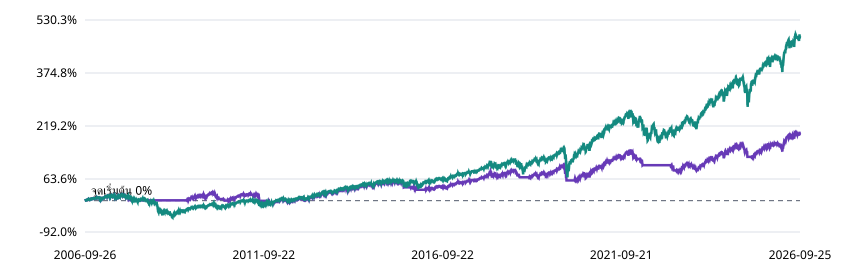

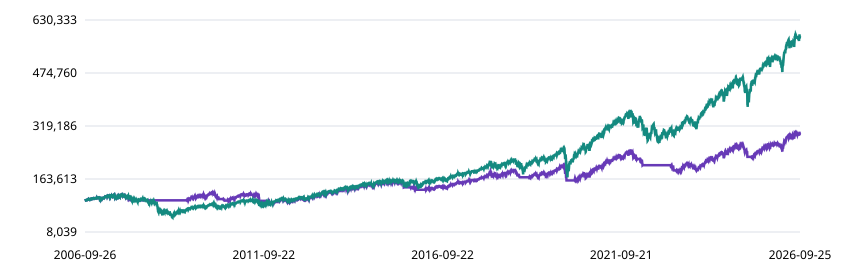

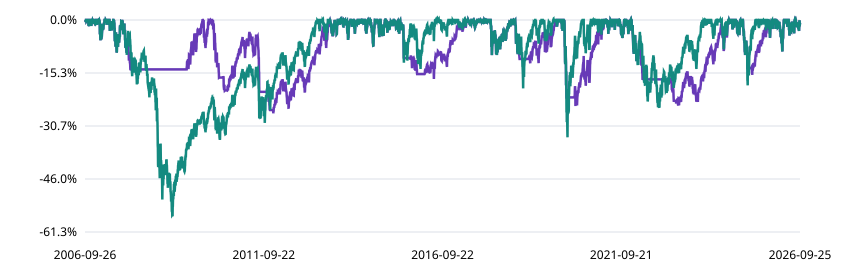

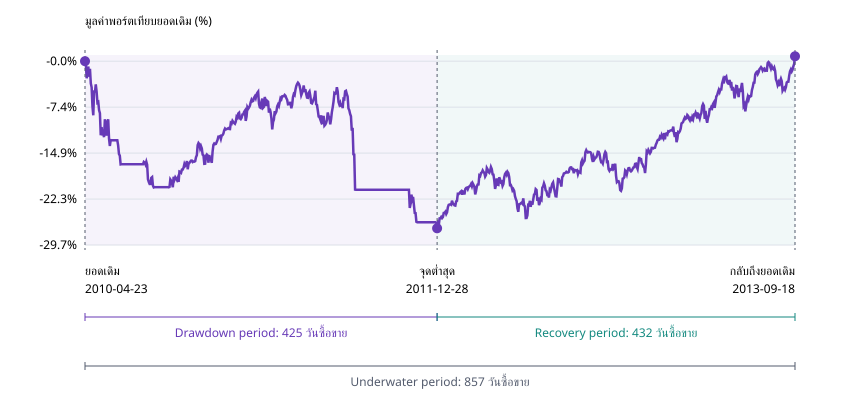

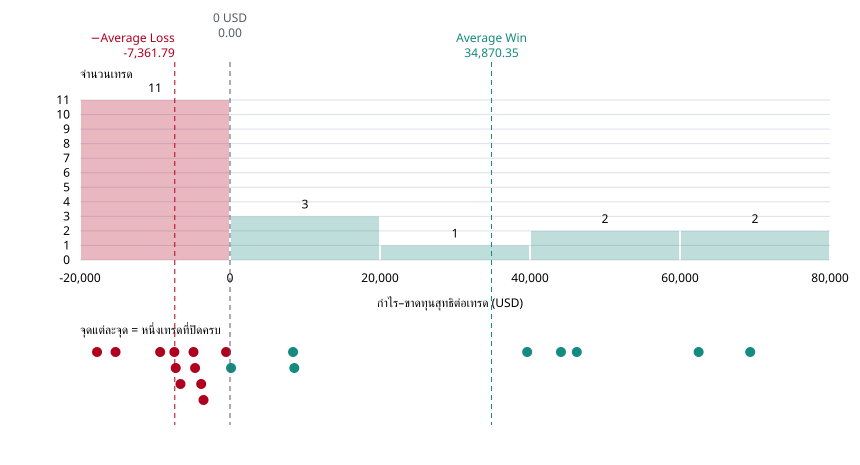

In [13]:
import re
report_html = (work_dir / "performance-report.html").read_text(encoding="utf-8")
for svg in re.findall(r"<svg.*?</svg>", report_html, flags=re.S):
    svg = svg.replace('<svg ', '<svg xmlns="http://www.w3.org/2000/svg" style="background:white;color:black;font:12px sans-serif" ', 1)
    display({'image/svg+xml': svg}, raw=True)


## ทดลองต้นทุนบนราคาชุดเดิม

0, 10 และ 20 bps เป็นสมมติฐานต้นทุนที่ทดลอง ไม่ใช่ราคาตลาดชุดใหม่ การเปลี่ยนต้นทุนต้องรันซื้อขายใหม่เพราะจำนวนหน่วยเปลี่ยนด้วย

In [14]:
for bps in [0, 10, 20]:
    scenario = lesson.make_results(lesson.run_backtest(bars, {'feeRatePerSide': bps/10000}))
    print(bps, 'bps/side:', f"{scenario['portfolioMetrics']['totalReturn']:.4%}",
          'final USD', f"{scenario['portfolioMetrics']['finalEquity']:,.2f}")


0 bps/side: 209.5244% final USD 309,524.42
10 bps/side: 197.9832% final USD 297,983.16
20 bps/side: 186.8722% final USD 286,872.22
